# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score, make_scorer

## 2. Datos

In [18]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [19]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 203.7 KB


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [20]:
df.duplicated().value_counts()

False    912
Name: count, dtype: int64

### 2.2 Definir X e y


In [21]:
X = df.drop(columns="Price_in_euros").copy()

In [22]:
y = df["Price_in_euros"]

### 2.3 Dividir en train y test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [24]:
X_train.head()
X_train.info()

<class 'pandas.DataFrame'>
Index: 729 entries, 25 to 102
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         729 non-null    int64  
 1   Company           729 non-null    str    
 2   Product           729 non-null    str    
 3   TypeName          729 non-null    str    
 4   Inches            729 non-null    float64
 5   ScreenResolution  729 non-null    str    
 6   Cpu               729 non-null    str    
 7   Ram               729 non-null    str    
 8   Memory            729 non-null    str    
 9   Gpu               729 non-null    str    
 10  OpSys             729 non-null    str    
 11  Weight            729 non-null    str    
dtypes: float64(1), int64(1), str(10)
memory usage: 163.5 KB


In [25]:
for i in X_train.columns:
    print(f"Análisis de {i}")
    print(X_train[i].value_counts())

Análisis de laptop_ID
laptop_ID
1118    1
153     1
275     1
1100    1
131     1
       ..
578     1
996     1
770     1
407     1
418     1
Name: count, Length: 729, dtype: int64
Análisis de Company
Company
Lenovo       162
Dell         158
HP           155
Asus         101
Acer          55
Toshiba       31
MSI           30
Apple         13
Mediacom       4
Razer          4
Microsoft      3
Samsung        3
Xiaomi         3
Google         2
Fujitsu        2
Vero           2
Chuwi          1
Name: count, dtype: int64
Análisis de Product
Product
XPS 13                                       20
Inspiron 3567                                17
ProBook 450                                  12
250 G6                                       12
EliteBook 840                                11
                                             ..
FX502VM-DM105T (i7-6700HQ/8GB/1TB/GeForce     1
GE72 Apache                                   1
Omen 15-ce006nv                               1
14-am079na (N371

In [26]:
texto = ['Company','Product','TypeName','ScreenResolution',
         'Cpu','Ram','Memory','Gpu','OpSys','Weight']

pd.DataFrame({
    'n_unicos': [X_train[c].nunique() for c in texto],
    '%_unicos': [round(100*X_train[c].nunique()/len(X_train), 1) for c in texto]
}).set_index(pd.Index(texto)).sort_values('n_unicos', ascending=False)

,n_unicos,%_unicos
Product,408,56.0
Weight,148,20.3
Cpu,93,12.8
Gpu,84,11.5
Memory,33,4.5
ScreenResolution,33,4.5
Company,17,2.3
OpSys,9,1.2
Ram,8,1.1
TypeName,6,0.8


In [27]:
for c in ['Company', 'TypeName', 'OpSys']:
    print(f"--- {c} ---")
    print(X_train[c].value_counts())
    print()

--- Company ---
Company
Lenovo       162
Dell         158
HP           155
Asus         101
Acer          55
Toshiba       31
MSI           30
Apple         13
Mediacom       4
Razer          4
Microsoft      3
Samsung        3
Xiaomi         3
Google         2
Fujitsu        2
Vero           2
Chuwi          1
Name: count, dtype: int64

--- TypeName ---
TypeName
Notebook              412
Gaming                113
Ultrabook             113
2 in 1 Convertible     62
Netbook                16
Workstation            13
Name: count, dtype: int64

--- OpSys ---
OpSys
Windows 10      596
No OS            39
Linux            37
Windows 7        24
Chrome OS        14
macOS             7
Mac OS X          6
Windows 10 S      5
Android           1
Name: count, dtype: int64



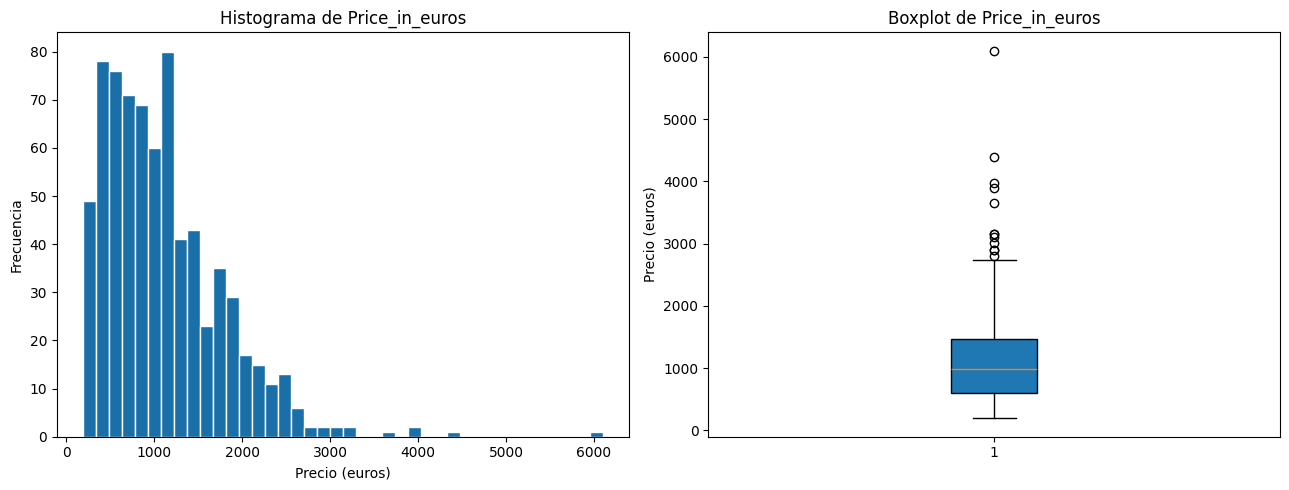

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(y_train, bins=40, color="#1a6fa8", edgecolor="white")
axes[0].set_title("Histograma de Price_in_euros")
axes[0].set_xlabel("Precio (euros)")
axes[0].set_ylabel("Frecuencia")

# Boxplot
axes[1].boxplot(y_train, patch_artist=True)
axes[1].set_title("Boxplot de Price_in_euros")
axes[1].set_ylabel("Precio (euros)")

plt.tight_layout()
plt.show()

Price         1.000000
Ram_num       0.744269
Weight_num    0.202341
Inches        0.051334
Name: Price, dtype: float64


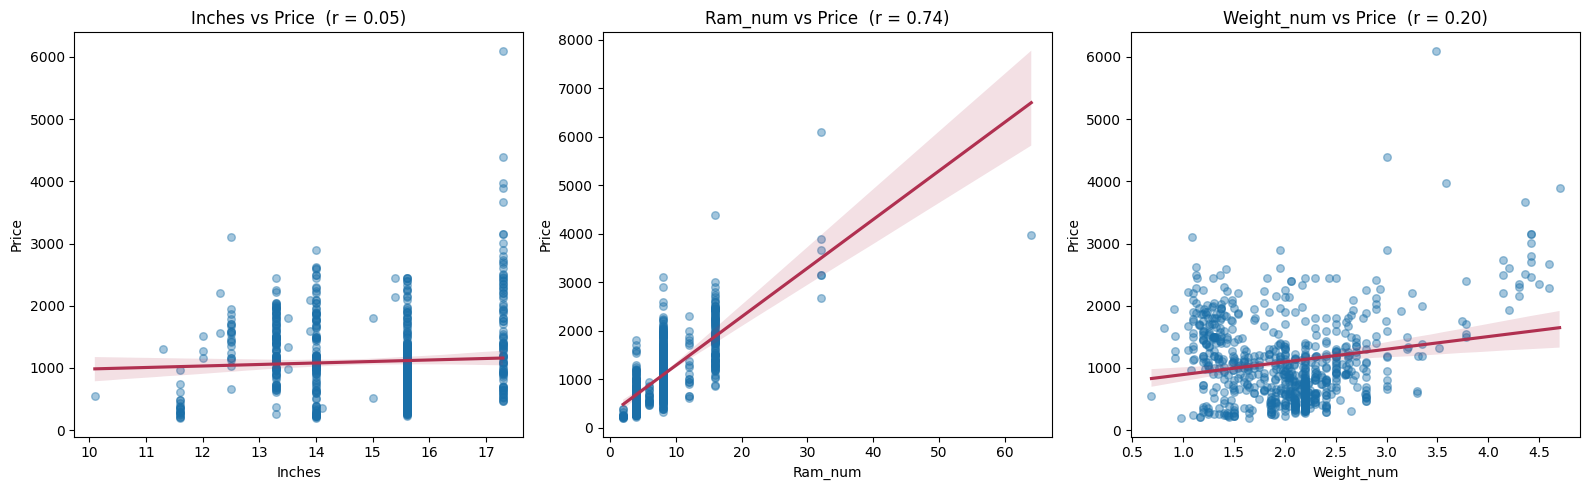

In [29]:
# Relación de cada variable numérica con el precio
eda = X_train.copy()
eda['Ram_num']    = eda['Ram'].str.replace('GB', '', regex=False).astype(int)
eda['Weight_num'] = eda['Weight'].str.replace('kg', '', regex=False).astype(float)
eda['Price']      = y_train

numericas = ['Inches', 'Ram_num', 'Weight_num']

# Correlación con el precio
print(eda[numericas + ['Price']].corr()['Price'].sort_values(ascending=False))

# Scatterplots con línea de tendencia (regresión) para ver la relación
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, numericas):
    sns.regplot(x=col, y='Price', data=eda, ax=ax,
                scatter_kws={'alpha': 0.4, 's': 30, 'color': '#1a6fa8'},
                line_kws={'color': '#b03050'})
    r = eda[col].corr(eda['Price'])
    ax.set_title(f"{col} vs Price  (r = {r:.2f})")

plt.tight_layout()
plt.show()

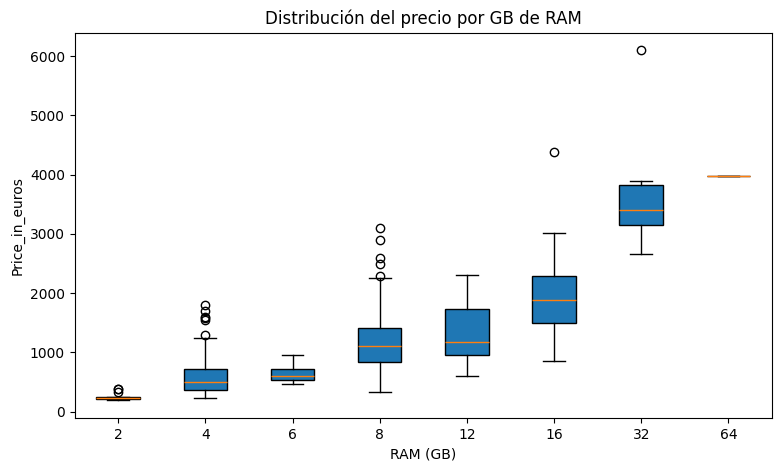

In [30]:
plt.figure(figsize=(9, 5))
niveles = sorted(eda['Ram_num'].unique())
datos   = [eda.loc[eda['Ram_num'] == n, 'Price'] for n in niveles]

plt.boxplot(datos, tick_labels=niveles, patch_artist=True)
plt.title("Distribución del precio por GB de RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price_in_euros")
plt.show()

El precio está muy concentrado en la zona baja y con una cola larga hacia la derecha. Le paso el logaritmo para ver si toma una forma normal..

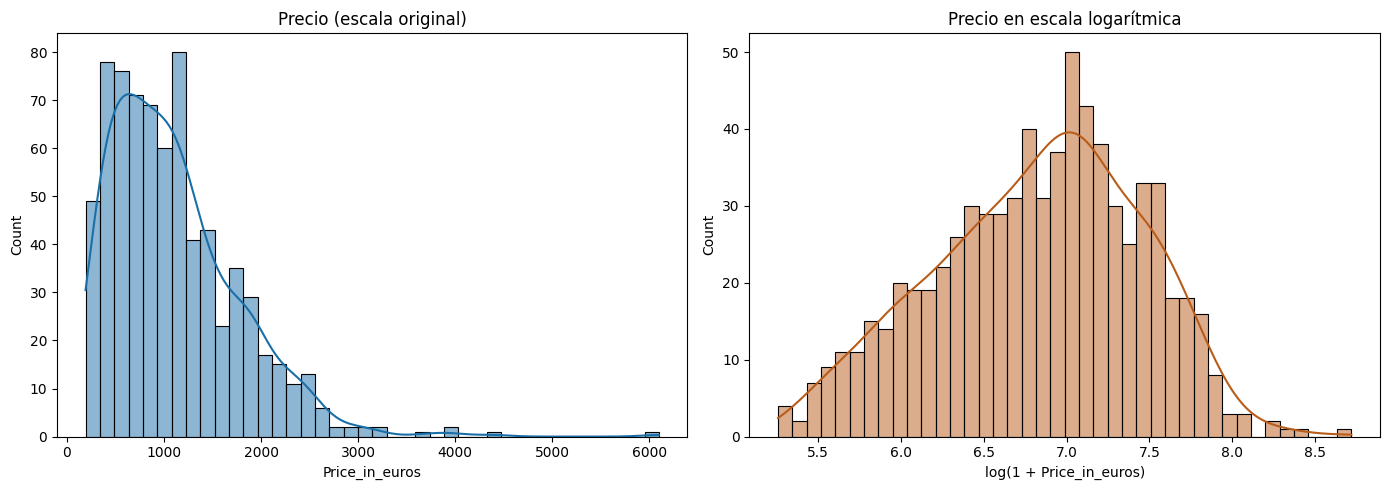

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio tal cual: muy asimétrico, con cola hacia los precios altos
sns.histplot(y_train, bins=40, kde=True, color="#1a6fa8", ax=axes[0])
axes[0].set_title("Precio (escala original)")
axes[0].set_xlabel("Price_in_euros")

# Precio en log: mucho más simétrico
sns.histplot(np.log1p(y_train), bins=40, kde=True, color="#b85c1a", ax=axes[1])
axes[1].set_title("Precio en escala logarítmica")
axes[1].set_xlabel("log(1 + Price_in_euros)")

plt.tight_layout()
plt.show()

In [32]:
# Preprocesador final: One-Hot a categóricas + Splines sobre numéricas escaladas.
# Los splines permiten que un modelo LINEAL capture relaciones no lineales
# (p.ej. que el precio crezca más rápido con RAM alta) sin dejar de ser lineal.
def construir_preprocesador():
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
        ('num', Pipeline([
            ('scaler', StandardScaler()),
            ('spline', SplineTransformer(n_knots=4, degree=3, extrapolation='linear'))
        ]), num)
    ])

### 3.1 Feature Engineering

La mayoría de columnas vienen como texto (`Cpu`, `Gpu`, `Memory`, `ScreenResolution`...) y muchas tienen demasiados valores distintos para meterlas tal cual. Lo que hago es sacar de cada una la información que de verdad influye en el precio: la gama del procesador, si la gráfica es dedicada, cuánto SSD lleva, la resolución de la pantalla, etc.

La función de abajo hace todo eso y la aplico igual a train y a test. `Product` la dejo fuera porque tiene casi un valor por equipo y no sirve para generalizar.

In [33]:
#import re

def feature_engineering(data):
    """Crea features numéricas a partir de las columnas de texto del dataset.

    Se aplica igual a train y a test para que ambos acaben con las mismas
    columnas. No borra ni añade filas, sólo columnas. Devuelve una copia.
    """
    d = data.copy()

    # Ram y Weight vienen como texto ("8GB", "1.86kg"). Los paso a número quitando la unidad
    d['Ram'] = d['Ram'].str.replace('GB', '', regex=False).astype(int)
    d['Weight'] = d['Weight'].str.replace('kg', '', regex=False).astype(float)

    # La columna Cpu mezcla marca, modelo y velocidad en un solo string.
    def cpu_tier(s):
        s = s.lower()
        # i3/i5/i7/i9 es lo que más mueve el precio en los Intel Core
        for t in ['core i3', 'core i5', 'core i7', 'core i9']:
            if t in s:
                return t.split()[-1]
        # el resto de familias se agrupan por nombre
        for k in ['celeron', 'pentium', 'ryzen', 'atom', 'xeon']:
            if k in s:
                return k
        if 'm3' in s or 'core m' in s:
            return 'core_m'
        if 'amd' in s:
            return 'amd_other'
        return 'otro'

    d['Cpu_tier'] = d['Cpu'].map(cpu_tier)
    d['Cpu_brand'] = d['Cpu'].str.split().str[0]                 # Intel o AMD
    d['Cpu_GHz'] = d['Cpu'].str.extract(r'(\d+\.?\d*)\s*GHz').astype(float)  # la velocidad
    # La generación Intel (i7-7500U -> 7) da idea de lo moderno que es el equipo.
    # Pongo 0 cuando no aplica (AMD, ARM, o cuando no aparece el modelo).
    def cpu_gen(s):
        m = re.search(r'i[3579]\s*-?\s*(\d)\d{3}', s)
        return int(m.group(1)) if m else 0
    d['Cpu_gen'] = d['Cpu'].apply(cpu_gen)

    # --- GPU ---
    # Lo que encarece un portátil no es la marca de la gráfica, sino si es dedicada
    # (juegos / diseño) o integrada. Saco tres señales de eso.
    d['Gpu_dedicated'] = d['Gpu'].str.contains(
        'GeForce|Radeon|GTX|RTX|Quadro|FirePro', case=False, regex=True).astype(int)
    d['Gpu_gaming'] = d['Gpu'].str.contains('GTX|RTX', case=False, regex=True).astype(int)
    # El número de serie de las Nvidia (1050, 1060, 2070...) es un buen proxy de potencia
    def gpu_serie(s):
        m = re.search(r'(?:GTX|RTX|GeForce)\s*(\d{3,4})', s)
        return int(m.group(1)) if m else 0
    d['Gpu_serie'] = d['Gpu'].apply(gpu_serie)

    # --- Memory ---
    # El texto puede tener uno o dos discos ("256GB SSD + 1TB HDD"). Separo la
    # capacidad por tipo, pasando siempre a GB (1 TB = 1024 GB). Un SSD vale más
    # que un HDD de la misma capacidad, por eso me interesa distinguirlos.
    def parse_mem(s, tipo):
        total = 0
        for part in s.split('+'):                  # recorro cada disco por separado
            if tipo in part:
                m = re.search(r'(\d+\.?\d*)\s*(TB|GB)', part)
                if m:
                    val = float(m.group(1))
                    if m.group(2) == 'TB':
                        val *= 1024
                    total += val
        return total

    d['SSD_GB'] = d['Memory'].apply(lambda s: parse_mem(s, 'SSD'))
    d['HDD_GB'] = d['Memory'].apply(lambda s: parse_mem(s, 'HDD'))
    d['Flash_GB'] = d['Memory'].apply(lambda s: parse_mem(s, 'Flash Storage'))
    d['Storage_total'] = d['SSD_GB'] + d['HDD_GB'] + d['Flash_GB']   # capacidad total
    d['has_SSD'] = (d['SSD_GB'] > 0).astype(int)   # llevar SSD encarece

    # --- Pantalla ---
    # ScreenResolution trae la resolución ("1920x1080") y a veces extras (IPS, táctil).
    res = d['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)
    d['screen_w'] = res[0]
    d['screen_h'] = res[1]
    d['pixels'] = res[0] * res[1]                                  # resolución total
    # PPI = densidad de píxeles (diagonal en px / pulgadas). Distingue una pantalla
    # nítida de una normal aunque tengan el mismo tamaño.
    d['ppi'] = np.sqrt(res[0]**2 + res[1]**2) / d['Inches']
    d['Touchscreen'] = d['ScreenResolution'].str.contains('Touchscreen', case=False).astype(int)
    d['IPS'] = d['ScreenResolution'].str.contains('IPS', case=False).astype(int)

    # --- Variables derivadas ---
    # weight_per_inch = lo "denso" que es el portátil (un gaming pesado pesa distinto
    # que un ultrabook del mismo tamaño). ram_x_ssd captura que RAM y SSD altos suelen
    # ir juntos en los equipos caros (uso log del SSD para que no se dispare).
    d['weight_per_inch'] = d['Weight'] / d['Inches']
    d['ram_x_ssd'] = d['Ram'] * np.log1p(d['SSD_GB'])

    # --- Marcas poco frecuentes ---
    # Las marcas con muy pocos equipos (Xiaomi, Chuwi...) generan columnas casi vacías
    # al hacer One-Hot y meten ruido. Las junto todas en "Other".
    raras = ['Xiaomi', 'Chuwi', 'Huawei', 'Google', 'Vero', 'Fujitsu', 'LG']
    d['Company_g'] = d['Company'].where(~d['Company'].isin(raras), 'Other')

    return d


# Columnas que le paso al modelo. Product se queda fuera a propósito: tiene 408
# valores distintos (casi uno por equipo), así que no ayuda.
num = ['Inches', 'Ram', 'Weight', 'Cpu_GHz', 'Cpu_gen',
       'Gpu_dedicated', 'Gpu_gaming', 'Gpu_serie',
       'SSD_GB', 'HDD_GB', 'Storage_total', 'has_SSD',
       'screen_w', 'screen_h', 'pixels', 'ppi', 'Touchscreen', 'IPS',
       'weight_per_inch', 'ram_x_ssd']
cat = ['Company_g', 'TypeName', 'OpSys', 'Cpu_tier']

In [34]:
# Aplico el feature engineering a train y a test
X_train_fe = feature_engineering(X_train)
X_test_fe  = feature_engineering(X_test)

# El preprocesador (One-Hot + escalado + splines) SÍ aprende de los datos, así que
# uso fit_transform en train (aprende y transforma) y transform en test (solo transforma,
# reutilizando lo aprendido en train). Así evito el data leakage.
preprocesador = construir_preprocesador()
X_train_prep = preprocesador.fit_transform(X_train_fe)
X_test_prep  = preprocesador.transform(X_test_fe)

print("Train procesado:", X_train_prep.shape)
print("Test procesado :", X_test_prep.shape)

Train procesado: (729, 158)
Test procesado : (183, 158)


In [35]:
X_train_fe.head(10)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,has_SSD,screen_w,screen_h,pixels,ppi,Touchscreen,IPS,weight_per_inch,ram_x_ssd,Company_g
25,1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8,1TB HDD,AMD FirePro W6150M,...,0,1920.0,1080.0,2073600.0,127.335675,0,1,0.173410,0.000000,HP
84,153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,512GB SSD,Nvidia GeForce GTX 1050,...,1,1920.0,1080.0,2073600.0,141.211998,0,0,0.164103,99.844414,Dell
10,275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8,512GB SSD,Intel Iris Graphics 550,...,1,2560.0,1600.0,4096000.0,226.983005,0,1,0.103008,49.922207,Apple
342,1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4,500GB HDD,Intel HD Graphics 520,...,0,1920.0,1080.0,2073600.0,157.350512,0,0,0.110000,0.000000,HP
890,131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16,256GB SSD + 2TB HDD,AMD Radeon 530,...,1,1920.0,1080.0,2073600.0,127.335675,0,0,0.161850,88.785217,Dell
396,1126,Dell,Vostro 3559,Notebook,15.6,1366x768,Intel Core i5 6200U 2.3GHz,4,500GB HDD,AMD Radeon R5 M315,...,0,1366.0,768.0,1049088.0,100.454670,0,0,0.143590,0.000000,Dell
744,203,HP,Probook 470,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Nvidia GeForce 930MX,...,1,1920.0,1080.0,2073600.0,127.335675,0,0,0.144509,44.392609,HP
823,853,Dell,Vostro 3568,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,128GB SSD,Intel HD Graphics 620,...,1,1366.0,768.0,1049088.0,100.454670,0,0,0.139744,38.878499,Dell
118,1244,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,...,1,3200.0,1800.0,5760000.0,276.053530,1,0,0.096992,44.392609,Dell
298,585,MSI,GT73VR Titan,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,...,1,1920.0,1080.0,2073600.0,127.335675,0,0,0.239306,99.844414,MSI


## 4. Modelado

### 4.1 Comparación de modelos

En lugar de elegir un modelo a ciegas, pruebo varios y dejo que el RMSE decida cuál va mejor: la regresión lineal (Ridge sobre las features con splines), un árbol de decisión, random forest y los tres boostings que hemos visto (XGBoost, LightGBM y CatBoost).

Para que la comparación sea justa, todos pasan por la misma validación cruzada de 5 folds y con el precio en logaritmo. La lineal usa el preprocesado con splines porque lo necesita para captar lo no lineal; a los árboles les basta con el One-Hot, así que a esos les paso las categóricas sin más.

In [36]:
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Preprocesado para los árboles: solo One-Hot, sin splines ni escalado (no los necesitan)
def preprocesador_arboles():
    return ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)],
        remainder='passthrough'
    )

# Para cada modelo guardo: una función que crea el modelo y otra que crea su preprocesador.
# Uso funciones (no instancias) para que cada vez se construya uno nuevo y limpio,
# sin arrastrar estado de un entrenamiento anterior.
modelos = {
    'Ridge + Splines': (lambda: Ridge(alpha=0.3),                        construir_preprocesador),
    'Decision Tree':   (lambda: DecisionTreeRegressor(random_state=42),  preprocesador_arboles),
    'Random Forest':   (lambda: RandomForestRegressor(n_estimators=500, max_depth=20,
                                   max_features='sqrt', random_state=42, n_jobs=-1), preprocesador_arboles),
    'XGBoost':         (lambda: XGBRegressor(random_state=42, verbosity=0),         preprocesador_arboles),
    'LightGBM':        (lambda: LGBMRegressor(random_state=42, verbose=-100),       preprocesador_arboles),
    'CatBoost':        (lambda: CatBoostRegressor(random_state=42, verbose=False,
                                   allow_writing_files=False),                       preprocesador_arboles),
}

### 4.2 Validación cruzada de cada modelo

Saco el RMSE medio de cada modelo con los 5 folds. El target va en log: el `TransformedTargetRegressor` aplica el `log1p` al entrenar y lo deshace al predecir, y lo hace dentro de cada fold para no colar información de un lado a otro.

In [37]:
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Datos con feature engineering sobre todo el conjunto de train
df_fe_cv = feature_engineering(df)
X_cv = df_fe_cv[num + cat]
y_cv = df_fe_cv['Price_in_euros']

resultados = {}
for nombre, (crear_modelo, crear_prep) in modelos.items():
    pipe = TransformedTargetRegressor(
        regressor=Pipeline([('prep', crear_prep()), ('model', crear_modelo())]),
        func=np.log1p, inverse_func=np.expm1
    )
    scores = -cross_val_score(pipe, X_cv, y_cv, scoring=rmse_scorer, cv=kf, n_jobs=-1)
    resultados[nombre] = scores.mean()
    print(f"{nombre:18} RMSE_CV: {scores.mean():.2f} +/- {scores.std():.2f}")

# Modelo con menor RMSE
ganador = min(resultados, key=resultados.get)
print(f"\nEl mejor modelo es: {ganador}  ({resultados[ganador]:.2f} euros)")

Ridge + Splines    RMSE_CV: 287.68 +/- 20.16
Decision Tree      RMSE_CV: 392.31 +/- 50.39
Random Forest      RMSE_CV: 291.13 +/- 53.60
XGBoost            RMSE_CV: 264.59 +/- 44.08
LightGBM           RMSE_CV: 274.33 +/- 33.13
CatBoost           RMSE_CV: 239.91 +/- 37.91

El mejor modelo es: CatBoost  (239.91 euros)


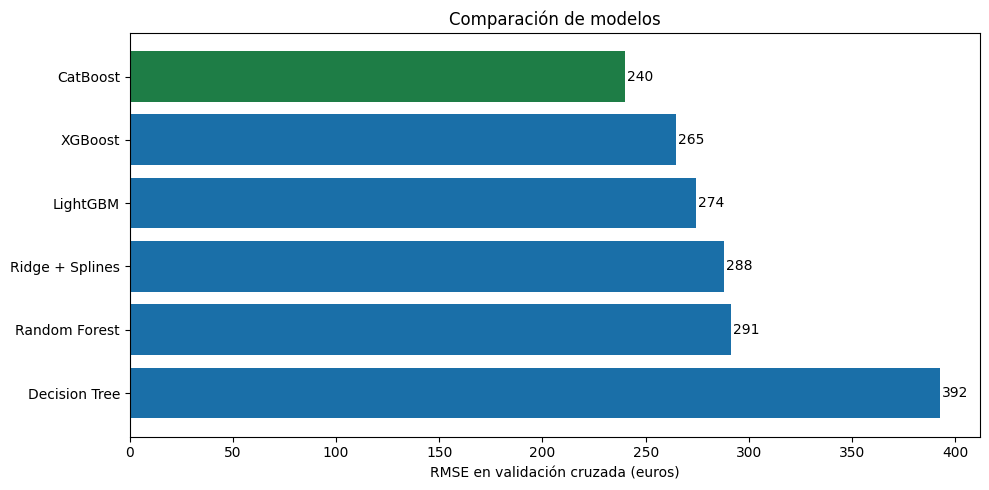

In [38]:
# Gráfica comparativa del RMSE de cada modelo
orden = sorted(resultados, key=resultados.get)
valores = [resultados[m] for m in orden]

plt.figure(figsize=(10, 5))
colores = ['#1e7d46' if m == ganador else '#1a6fa8' for m in orden]
plt.barh(orden, valores, color=colores)
plt.xlabel("RMSE en validación cruzada (euros)")
plt.title("Comparación de modelos")
plt.gca().invert_yaxis()
for i, v in enumerate(valores):
    plt.text(v + 1, i, f"{v:.0f}", va='center')
plt.tight_layout()
plt.show()

### 4.3 Validación del modelo ganador

Con el mejor modelo ya elegido, lo entreno con el train del split y miro qué RMSE y R² da sobre `X_test`, que no he usado para elegirlo. Así compruebo que el resultado de la CV se mantiene.

In [39]:
# Recupero el modelo ganador y su preprocesado (instanciando frescos)
crear_modelo, crear_prep = modelos[ganador]

modelo = TransformedTargetRegressor(
    regressor=Pipeline([('prep', crear_prep()), ('model', crear_modelo())]),
    func=np.log1p, inverse_func=np.expm1
)
modelo.fit(X_train_fe[num + cat], y_train)

# Métricas sobre el conjunto de validación
pred = modelo.predict(X_test_fe[num + cat])
rmse = root_mean_squared_error(y_test, pred)
r2   = r2_score(y_test, pred)

print(f"Modelo final: {ganador}")
print(f"RMSE: {rmse:.2f} euros")
print(f"R2  : {r2:.4f}")

Modelo final: CatBoost
RMSE: 269.07 euros
R2  : 0.8694


### 4.4 Optimización del ganador con GridSearch

El ganador lo he probado con sus parámetros por defecto. Ahora le busco los mejores hiperparámetros con `GridSearchCV`, que prueba **todas** las combinaciones de la rejilla (a diferencia del RandomSearch, que prueba solo unas cuantas al azar). Para un grid pequeño como este merece la pena hacerlo exhaustivo.

Tengo una rejilla preparada para cada modelo, así que uso la que corresponda al que haya ganado.

In [40]:
# Rejilla de hiperparámetros por modelo (los nombres llevan el prefijo del pipeline:
# 'regressor__model__' porque el modelo va dentro de un Pipeline envuelto en
# TransformedTargetRegressor)
grids = {
    'Ridge + Splines': {
        'regressor__model__alpha': [0.1, 0.3, 0.5, 1.0],
    },
    'Decision Tree': {
        'regressor__model__max_depth': [4, 8, 12, None],
        'regressor__model__min_samples_leaf': [1, 5, 10],
    },
    'Random Forest': {
        'regressor__model__n_estimators': [300, 500],
        'regressor__model__max_depth': [10, 20, None],
        'regressor__model__max_features': ['sqrt', 0.5],
    },
    'XGBoost': {
        'regressor__model__max_depth': [3, 6, 10],
        'regressor__model__learning_rate': [0.05, 0.1, 0.2],
        'regressor__model__n_estimators': [300, 500],
    },
    'LightGBM': {
        'regressor__model__max_depth': [4, 8, 12],
        'regressor__model__learning_rate': [0.05, 0.1],
        'regressor__model__n_estimators': [300, 500],
    },
    'CatBoost': {
        'regressor__model__depth': [4, 6, 8],
        'regressor__model__learning_rate': [0.03, 0.05, 0.1],
        'regressor__model__iterations': [300, 500],
    },
}

# Pipeline del ganador (modelo + preprocesado frescos), con target en log
crear_modelo, crear_prep = modelos[ganador]
pipe_ganador = TransformedTargetRegressor(
    regressor=Pipeline([('prep', crear_prep()), ('model', crear_modelo())]),
    func=np.log1p, inverse_func=np.expm1
)

# GridSearch sobre la rejilla del ganador
grid_search = GridSearchCV(
    pipe_ganador,
    param_grid=grids[ganador],
    scoring=rmse_scorer,
    cv=kf,
    n_jobs=-1
)
grid_search.fit(X_cv, y_cv)

print(f"Modelo optimizado: {ganador}")
print("Mejores hiperparámetros:")
for k, v in grid_search.best_params_.items():
    print(f"  {k.split('__')[-1]}: {v}")
print(f"\nRMSE por defecto : {resultados[ganador]:.2f} euros")
print(f"RMSE optimizado  : {-grid_search.best_score_:.2f} euros")

Modelo optimizado: CatBoost
Mejores hiperparámetros:
  depth: 4
  iterations: 500
  learning_rate: 0.1

RMSE por defecto : 239.91 euros
RMSE optimizado  : 237.51 euros


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Ya que tengo el modelo elegido y validado, lo vuelvo a entrenar con todo `train.csv`, no solo con el 80% del split. El split me servía para comparar de forma honesta, pero para la predicción final cuantos más datos vea el modelo, mejor.

In [41]:
# Feature engineering sobre todo df
df_fe = feature_engineering(df)
X_full = df_fe[num + cat]
y_full = df_fe['Price_in_euros']

# Modelo final = el ganador YA OPTIMIZADO por GridSearch, reentrenado con el 100%
# de los datos. Tomo la mejor combinación de hiperparámetros encontrada y la
# reentreno desde cero sobre todo el conjunto.
modelo_final = grid_search.best_estimator_
modelo_final.fit(X_full, y_full)

print(f"Modelo final entrenado: {ganador} (optimizado)")

Modelo final entrenado: CatBoost (optimizado)


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [42]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [43]:
# Aplicamos EXACTAMENTE el mismo feature engineering (no elimina filas)
X_pred_fe = feature_engineering(X_pred)

# El modelo_final es un Pipeline completo: hace One-Hot, splines y escalado internamente.
# Solo necesitamos pasarle las columnas correctas.
X_pred_final = X_pred_fe[num + cat]

print("Shape test procesado:", X_pred_final.shape)

Shape test procesado: (391, 24)


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [44]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [45]:
# modelo_final es un TransformedTargetRegressor: ya deshace el log internamente,
# así que NO hay que aplicar expm1 otra vez (hacerlo dos veces produce 'inf').
submission = pd.DataFrame({
    'laptop_ID': X_pred['laptop_ID'],
    'Price_in_euros': modelo_final.predict(X_pred_final)
})
submission

,laptop_ID,Price_in_euros
0,209,1420.200641
1,1281,273.927318
2,1168,354.992143
3,1231,1007.743378
4,1020,1025.822878
...,...,...
386,820,2266.960059
387,948,947.702784
388,483,1656.993700
389,1017,815.338886


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [46]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [47]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260701_183814.csv'. ¡A Kaggle!
